In [134]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/taeefnajib/used-car-price-prediction-dataset/used_cars.csv


In [135]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

# 1. Загрузка датасета

In [136]:
data = "/kaggle/input/datasets/taeefnajib/used-car-price-prediction-dataset/used_cars.csv"
df = pd.read_csv(data)

In [137]:
df.shape

(4009, 12)

In [138]:
print('Все колонки:', df.columns.tolist())
df.info()

Все колонки: ['brand', 'model', 'model_year', 'milage', 'fuel_type', 'engine', 'transmission', 'ext_col', 'int_col', 'accident', 'clean_title', 'price']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4009 entries, 0 to 4008
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   brand         4009 non-null   object
 1   model         4009 non-null   object
 2   model_year    4009 non-null   int64 
 3   milage        4009 non-null   object
 4   fuel_type     3839 non-null   object
 5   engine        4009 non-null   object
 6   transmission  4009 non-null   object
 7   ext_col       4009 non-null   object
 8   int_col       4009 non-null   object
 9   accident      3896 non-null   object
 10  clean_title   3413 non-null   object
 11  price         4009 non-null   object
dtypes: int64(1), object(11)
memory usage: 376.0+ KB


# 2. EDA

In [139]:
df.head()

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,Ford,Utility Police Interceptor Base,2013,"51,000 mi.",E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,"$10,300"
1,Hyundai,Palisade SEL,2021,"34,742 mi.",Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,"$38,005"
2,Lexus,RX 350 RX 350,2022,"22,372 mi.",Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,NaN,"$54,598"
3,INFINITI,Q50 Hybrid Sport,2015,"88,900 mi.",Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,Yes,"$15,500"
4,Audi,Q3 45 S line Premium Plus,2021,"9,835 mi.",Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,NaN,"$34,999"


In [140]:
df.describe().round(2)

,model_year
count,4009.00
mean,2015.52
std,6.10
min,1974.00
25%,2012.00
50%,2017.00
75%,2020.00
max,2024.00


In [141]:
df.isnull().sum()

brand             0
model             0
model_year        0
milage            0
fuel_type       170
engine            0
transmission      0
ext_col           0
int_col           0
accident        113
clean_title     596
price             0
dtype: int64

In [142]:
df = df.dropna()
df.isnull().sum()
#Мне кажется что будет странно заполнять fuel_type и accident медианными значениями или чем-либо другим, машина с v6 не может быть электричкой априори
#Что касается clean_title, все машины оказались "чистыми", позже этот столбец я вовсе откинул из-за неинформативности

brand           0
model           0
model_year      0
milage          0
fuel_type       0
engine          0
transmission    0
ext_col         0
int_col         0
accident        0
clean_title     0
price           0
dtype: int64

In [143]:
# Очищаем milage и price от лишних символов и переводим в int
df['milage'] = df['milage'].astype(str).str.replace(r'\D', '', regex=True).astype(int)
df['price'] = df['price'].astype(str).str.replace(r'\D', '', regex=True).astype(int)

# Проверяем dtypes
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3269 entries, 0 to 4008
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   brand         3269 non-null   object
 1   model         3269 non-null   object
 2   model_year    3269 non-null   int64 
 3   milage        3269 non-null   int64 
 4   fuel_type     3269 non-null   object
 5   engine        3269 non-null   object
 6   transmission  3269 non-null   object
 7   ext_col       3269 non-null   object
 8   int_col       3269 non-null   object
 9   accident      3269 non-null   object
 10  clean_title   3269 non-null   object
 11  price         3269 non-null   int64 
dtypes: int64(3), object(9)
memory usage: 332.0+ KB


In [144]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3269 entries, 0 to 4008
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   brand         3269 non-null   object
 1   model         3269 non-null   object
 2   model_year    3269 non-null   int64 
 3   milage        3269 non-null   int64 
 4   fuel_type     3269 non-null   object
 5   engine        3269 non-null   object
 6   transmission  3269 non-null   object
 7   ext_col       3269 non-null   object
 8   int_col       3269 non-null   object
 9   accident      3269 non-null   object
 10  clean_title   3269 non-null   object
 11  price         3269 non-null   int64 
dtypes: int64(3), object(9)
memory usage: 332.0+ KB


<Figure size 800x400 with 0 Axes>

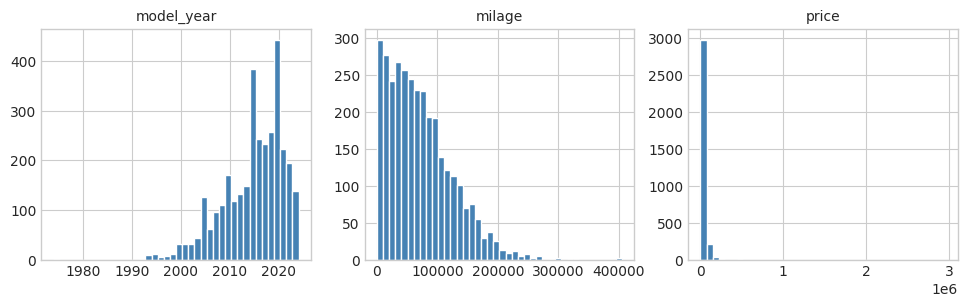

<Figure size 800x400 with 0 Axes>

In [145]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

n_cols = len(numeric_cols)
n_rows = (n_cols + 3) // 4
fig, axes = plt.subplots(n_rows, 4, figsize=(16, n_rows * 3))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    df[col].hist(bins=40, ax=axes[i], color='steelblue', edgecolor='white')
    axes[i].set_title(col, fontsize=10)

for j in range(len(numeric_cols), len(axes)):
    axes[j].set_visible(False)

plt.figure(figsize=(8, 4))

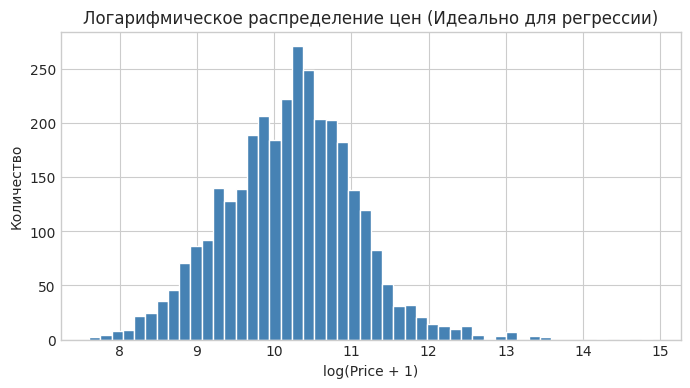

In [146]:
import numpy as np

plt.figure(figsize=(8, 4))
# Применяем логарифм к цене для "сглаживания" распределения цены
np.log1p(df['price']).hist(bins=50, color='steelblue', edgecolor='white')
plt.title('Логарифмическое распределение цен (Идеально для регрессии)')
plt.xlabel('log(Price + 1)')
plt.ylabel('Количество')
plt.show()

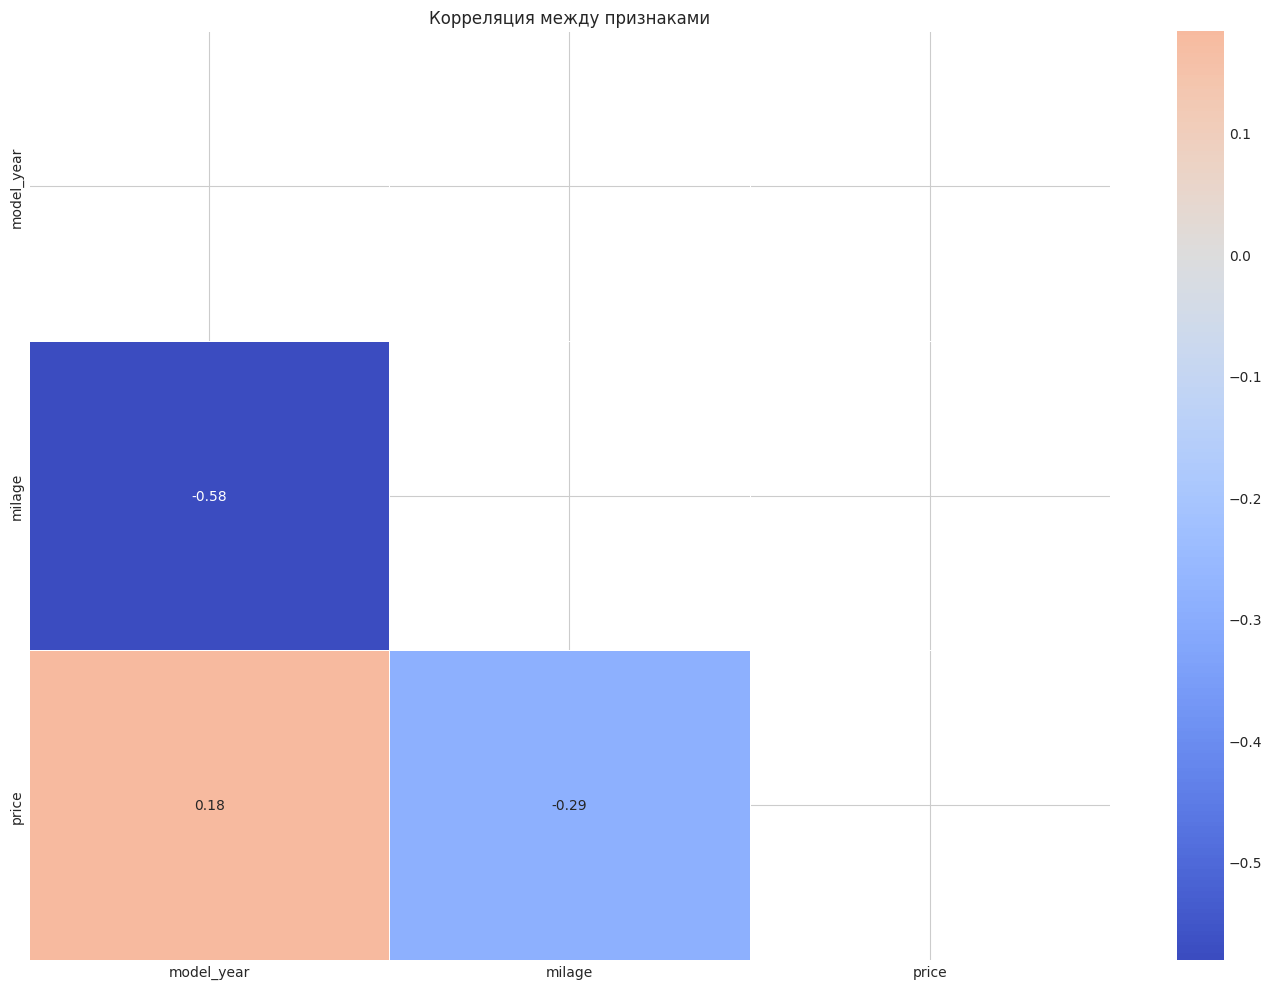

In [147]:
plt.figure(figsize=(14, 10))
corr = df[numeric_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Корреляция между признаками')
plt.tight_layout()
plt.show()

In [148]:
df.head()

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,Ford,Utility Police Interceptor Base,2013,51000,E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,10300
1,Hyundai,Palisade SEL,2021,34742,Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,38005
3,INFINITI,Q50 Hybrid Sport,2015,88900,Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,Yes,15500
6,Audi,S3 2.0T Premium Plus,2017,84000,Gasoline,292.0HP 2.0L 4 Cylinder Engine Gasoline Fuel,6-Speed A/T,Blue,Black,None reported,Yes,31000
7,BMW,740 iL,2001,242000,Gasoline,282.0HP 4.4L 8 Cylinder Engine Gasoline Fuel,A/T,Green,Green,None reported,Yes,7300


In [149]:
print(df['fuel_type'].value_counts())

fuel_type
Gasoline          2815
Hybrid             145
E85 Flex Fuel      128
Diesel             102
–                   44
Plug-In Hybrid      33
not supported        2
Name: count, dtype: int64


In [150]:
# Заменяем мусорные значения на понятное 'Unknown'
df['fuel_type'] = df['fuel_type'].replace(['-', 'not supported'], 'Unknown')

In [151]:
print(df['brand'].value_counts())

brand
Ford             341
BMW              316
Mercedes-Benz    268
Chevrolet        259
Toyota           171
Porsche          158
Audi             153
Lexus            136
Jeep             114
Land             100
Nissan            95
Cadillac          92
GMC               84
Dodge             84
RAM               72
Subaru            59
Hyundai           57
Mazda             57
INFINITI          54
Volkswagen        51
Honda             49
Kia               46
Acura             45
Lincoln           44
Jaguar            39
Volvo             33
MINI              31
Maserati          31
Bentley           27
Buick             25
Chrysler          25
Mitsubishi        20
Genesis           16
Hummer            16
Pontiac           15
Lamborghini       15
Alfa              12
Rolls-Royce       10
Ferrari            9
Aston              8
Scion              6
Saturn             5
FIAT               4
McLaren            4
Mercury            3
Lotus              3
Saab               2
Bugatti

In [152]:
print(df['engine'].value_counts())

engine
355.0HP 5.3L 8 Cylinder Engine Gasoline Fuel             48
420.0HP 6.2L 8 Cylinder Engine Gasoline Fuel             46
–                                                        44
300.0HP 3.0L Straight 6 Cylinder Engine Gasoline Fuel    42
240.0HP 2.0L 4 Cylinder Engine Gasoline Fuel             42
                                                         ..
362.0HP 5.4L 8 Cylinder Engine Gasoline Fuel              1
134.0HP 1.8L 4 Cylinder Engine Plug-In Electric/Gas       1
120.0HP 2.2L 4 Cylinder Engine Flex Fuel Capability       1
715.0HP 5.2L 12 Cylinder Engine Gasoline Fuel             1
282.0HP 4.4L 8 Cylinder Engine Gasoline Fuel              1
Name: count, Length: 963, dtype: int64


In [153]:
print(df['transmission'].value_counts())

transmission
A/T                                  939
8-Speed A/T                          391
Transmission w/Dual Shift Mode       389
6-Speed A/T                          354
6-Speed M/T                          238
7-Speed A/T                          201
10-Speed A/T                         115
5-Speed A/T                           84
9-Speed A/T                           73
4-Speed A/T                           72
CVT Transmission                      62
8-Speed Automatic                     62
5-Speed M/T                           57
6-Speed Automatic                     39
M/T                                   38
10-Speed Automatic                    35
Automatic                             30
9-Speed Automatic                     26
Automatic CVT                         11
7-Speed M/T                            9
7-Speed Automatic with Auto-Shift      8
Transmission Overdrive Switch          7
6-Speed Manual                         5
8-Speed Automatic with Auto-Shift      5
6-S

# 3. Подготовка данных

In [154]:
def group_transmission(text):
    text = str(text).lower()
    if '-' in text and text.split('-')[0].isdigit() and len(text.split('-')) == 2 and text.split('-')[1] == 'speed':
        # Костыль для строки типа '7-Speed', где нет букв AT/MT
        return 'Automatic' 
    if 'manual' in text or 'm/t' in text or 'mt' in text:
        return 'Manual'
    elif 'cvt' in text:
        return 'CVT'
    elif 'auto' in text or 'a/t' in text or 'at' in text or 'dual shift' in text or 'overdrive' in text:
        return 'Automatic'
    else:
        return 'Unknown'

# Применяем группировку
df['transmission_type'] = df['transmission'].apply(group_transmission)

print(df['transmission_type'].value_counts())

transmission_type
Automatic    2846
Manual        348
CVT            73
Unknown         2
Name: count, dtype: int64


In [155]:
df['gears_count'] = df['transmission'].str.extract(r'(\d+)-Speed').astype(float)

# Заполняем пропуски (где количество передач не указано) медианой
# Для автоматов это обычно 6 или 8 передач, медиана по датасету будет идеальным решением
df['gears_count'] = df['gears_count'].fillna(df['gears_count'].median())

print(df['gears_count'].value_counts())

gears_count
7.0     1702
6.0      640
8.0      458
10.0     150
5.0      145
9.0       99
4.0       75
Name: count, dtype: int64


In [156]:
df.drop(columns=['transmission','ext_col','int_col','clean_title'])

,brand,model,model_year,milage,fuel_type,engine,accident,price,transmission_type,gears_count
0,Ford,Utility Police Interceptor Base,2013,51000,E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,At least 1 accident or damage reported,10300,Automatic,6.0
1,Hyundai,Palisade SEL,2021,34742,Gasoline,3.8L V6 24V GDI DOHC,At least 1 accident or damage reported,38005,Automatic,8.0
3,INFINITI,Q50 Hybrid Sport,2015,88900,Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,None reported,15500,Automatic,7.0
6,Audi,S3 2.0T Premium Plus,2017,84000,Gasoline,292.0HP 2.0L 4 Cylinder Engine Gasoline Fuel,None reported,31000,Automatic,6.0
7,BMW,740 iL,2001,242000,Gasoline,282.0HP 4.4L 8 Cylinder Engine Gasoline Fuel,None reported,7300,Automatic,7.0
...,...,...,...,...,...,...,...,...,...,...
4003,Mercedes-Benz,E-Class E 300 4MATIC,2018,53705,Gasoline,241.0HP 2.0L 4 Cylinder Engine Gasoline Fuel,At least 1 accident or damage reported,25900,Automatic,7.0
4004,Bentley,Continental GT Speed,2023,714,Gasoline,6.0L W12 48V PDI DOHC Twin Turbo,None reported,349950,Automatic,8.0
4005,Audi,S4 3.0T Premium Plus,2022,10900,Gasoline,349.0HP 3.0L V6 Cylinder Engine Gasoline Fuel,None reported,53900,Automatic,7.0
4007,Ford,F-150 Raptor,2020,33000,Gasoline,450.0HP 3.5L V6 Cylinder Engine Gasoline Fuel,None reported,62999,Automatic,7.0


In [157]:
print(df['accident'].value_counts())

accident
None reported                             2332
At least 1 accident or damage reported     937
Name: count, dtype: int64


In [158]:
print(df['clean_title'].value_counts())

clean_title
Yes    3269
Name: count, dtype: int64


In [159]:
brand_market_price = df.groupby('brand')['price'].mean()
# Не делал отдельную диаграмму в EDA, поскольку она получилась просто отвратительной. 
# В датасете около 30 марок автомобилей и легче было их сгрупировать по сегменту

def get_segment(brand):
    price = brand_market_price[brand]
    if price < 20000:
        return 'Budget'
    elif price < 45000:
        return 'Medium'
    elif price < 90000:
        return 'Premium'
    else:
        return 'Luxury'

df['brand_segment'] = df['brand'].apply(get_segment)

df = pd.get_dummies(df, columns=['brand_segment'], drop_first=True)
df = df.drop(columns=['brand'])

In [160]:
df.head()

,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price,transmission_type,gears_count,brand_segment_Luxury,brand_segment_Medium,brand_segment_Premium
0,Utility Police Interceptor Base,2013,51000,E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,10300,Automatic,6.0,False,True,False
1,Palisade SEL,2021,34742,Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,38005,Automatic,8.0,False,False,False
3,Q50 Hybrid Sport,2015,88900,Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,Yes,15500,Automatic,7.0,False,True,False
6,S3 2.0T Premium Plus,2017,84000,Gasoline,292.0HP 2.0L 4 Cylinder Engine Gasoline Fuel,6-Speed A/T,Blue,Black,None reported,Yes,31000,Automatic,6.0,False,True,False
7,740 iL,2001,242000,Gasoline,282.0HP 4.4L 8 Cylinder Engine Gasoline Fuel,A/T,Green,Green,None reported,Yes,7300,Automatic,7.0,False,True,False


In [161]:
df['accident'] = (df['accident'] != 'None reported').astype(int)
df['clean_title'] = (df['clean_title'] == 'Yes').astype(int)

df['engine_hp'] = df['engine'].str.extract(r'(\d+\.?\d*)HP').astype(float)
df['engine_hp'] = df['engine_hp'].fillna(df['engine_hp'].median())

df['car_age'] = 2024 - df['model_year']

drop_cols = ['model', 'engine', 'transmission', 'ext_col', 'int_col', 'model_year']
df = df.drop(columns=[col for col in drop_cols if col in df.columns])

df = pd.get_dummies(df, columns=['fuel_type', 'transmission_type'], drop_first=True)

df = df.astype({col: int for col in df.select_dtypes(include='bool').columns})

In [162]:
df.head()

,milage,accident,clean_title,price,gears_count,brand_segment_Luxury,brand_segment_Medium,brand_segment_Premium,engine_hp,car_age,fuel_type_E85 Flex Fuel,fuel_type_Gasoline,fuel_type_Hybrid,fuel_type_Plug-In Hybrid,fuel_type_Unknown,fuel_type_–,transmission_type_CVT,transmission_type_Manual,transmission_type_Unknown
0,51000,1,1,10300,6.0,0,1,0,300.0,11,1,0,0,0,0,0,0,0,0
1,34742,1,1,38005,8.0,0,0,0,310.0,3,0,1,0,0,0,0,0,0,0
3,88900,0,1,15500,7.0,0,1,0,354.0,9,0,0,1,0,0,0,0,0,0
6,84000,0,1,31000,6.0,0,1,0,292.0,7,0,1,0,0,0,0,0,0,0
7,242000,0,1,7300,7.0,0,1,0,282.0,23,0,1,0,0,0,0,0,0,0


In [163]:
print(df['fuel_type_–'].value_counts())

fuel_type_–
0    3225
1      44
Name: count, dtype: int64


In [164]:
# Если вы объединяете на этапе OHE (One-Hot Encoding):
# Объединяем значения 1 из столбца 'fuel_type_–' в 'fuel_type_Unknown'
if 'fuel_type_–' in df.columns:
    df['fuel_type_Unknown'] = df['fuel_type_Unknown'] | df['fuel_type_–']
    df = df.drop(columns=['fuel_type_–'])

In [165]:
df.head()

,milage,accident,clean_title,price,gears_count,brand_segment_Luxury,brand_segment_Medium,brand_segment_Premium,engine_hp,car_age,fuel_type_E85 Flex Fuel,fuel_type_Gasoline,fuel_type_Hybrid,fuel_type_Plug-In Hybrid,fuel_type_Unknown,transmission_type_CVT,transmission_type_Manual,transmission_type_Unknown
0,51000,1,1,10300,6.0,0,1,0,300.0,11,1,0,0,0,0,0,0,0
1,34742,1,1,38005,8.0,0,0,0,310.0,3,0,1,0,0,0,0,0,0
3,88900,0,1,15500,7.0,0,1,0,354.0,9,0,0,1,0,0,0,0,0
6,84000,0,1,31000,6.0,0,1,0,292.0,7,0,1,0,0,0,0,0,0
7,242000,0,1,7300,7.0,0,1,0,282.0,23,0,1,0,0,0,0,0,0


In [166]:
print(df['clean_title'].value_counts())

clean_title
1    3269
Name: count, dtype: int64


In [167]:
# Удаляем константный столбец clean_title
df = df.drop(columns=['clean_title'])

In [168]:
df.head()

,milage,accident,price,gears_count,brand_segment_Luxury,brand_segment_Medium,brand_segment_Premium,engine_hp,car_age,fuel_type_E85 Flex Fuel,fuel_type_Gasoline,fuel_type_Hybrid,fuel_type_Plug-In Hybrid,fuel_type_Unknown,transmission_type_CVT,transmission_type_Manual,transmission_type_Unknown
0,51000,1,10300,6.0,0,1,0,300.0,11,1,0,0,0,0,0,0,0
1,34742,1,38005,8.0,0,0,0,310.0,3,0,1,0,0,0,0,0,0
3,88900,0,15500,7.0,0,1,0,354.0,9,0,0,1,0,0,0,0,0
6,84000,0,31000,6.0,0,1,0,292.0,7,0,1,0,0,0,0,0,0
7,242000,0,7300,7.0,0,1,0,282.0,23,0,1,0,0,0,0,0,0


In [169]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

X = df.drop(columns=['price'])
y_raw = df['price']
y_log = np.log1p(df['price'])

X_train, X_test, y_train_raw, y_test_raw, y_train_log, y_test_log = train_test_split(
    X, y_raw, y_log, test_size=0.2, random_state=42
)

scaler_reg = StandardScaler() #-> (X - X_train.mean()) / X_train.std() -> [0, 1]
X_train_reg = scaler_reg.fit_transform(X_train)
X_test_reg = scaler_reg.transform(X_test)

In [170]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.model_selection import KFold, cross_val_score

pipe_ridge = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge', Ridge(alpha=1.0))
])

kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(
    pipe_ridge, X_train, y_train_log, cv=kf, scoring='r2'
)

print(f"Средний R² на кросс-валидации: {cv_scores.mean():.5f}")

Средний R² на кросс-валидации: 0.77074


# 4. Обучение моделей

Модели для обучения:
- Ridge
- DecisionTreeRegressor
- CatBoostRegressor

In [171]:
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.metrics import r2_score, mean_absolute_error

pipe_ridge = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge', Ridge(random_state=42))
])

param_grid = {
    'ridge__alpha': [10.0, 11.0, 12.0, 14.0, 15.0, 16.0, 17.0, 18.0, 20.0]
}

kf = KFold(n_splits=5, shuffle=True, random_state=42)

grid_ridge = GridSearchCV(
    pipe_ridge, 
    param_grid, 
    cv=kf, 
    scoring='r2', 
    n_jobs=-1
)
grid_ridge.fit(X_train, y_train_log)

best_model = grid_ridge.best_estimator_
ridge_cv_score = grid_ridge.best_score_

print(f"Лучшее значение alpha: {grid_ridge.best_params_['ridge__alpha']}")
print(f"Лучший R² на кросс-валидации: {ridge_cv_score:.4f}")

# Оценка в логарифмическом масштабе
preds_log = best_model.predict(X_test)
r2_log = r2_score(y_test_log, preds_log)

# Оценка в реальных долларах
preds_price = np.expm1(preds_log)
y_test_price = np.expm1(y_test_log)

mae_dollars = mean_absolute_error(y_test_price, preds_price)
r2_dollars = r2_score(y_test_price, preds_price)

print(f"R² в логарифмах (для сравнения с CV): {r2_log:.4f}")
print(f"Тестовый R² (в $): {r2_dollars:.4f}")
print(f"Тестовый MAE (в $): ${mae_dollars:,.2f}")

Лучшее значение alpha: 17.0
Лучший R² на кросс-валидации: 0.7708
R² в логарифмах (для сравнения с CV): 0.7629
Тестовый R² (в $): 0.0747
Тестовый MAE (в $): $15,640.30


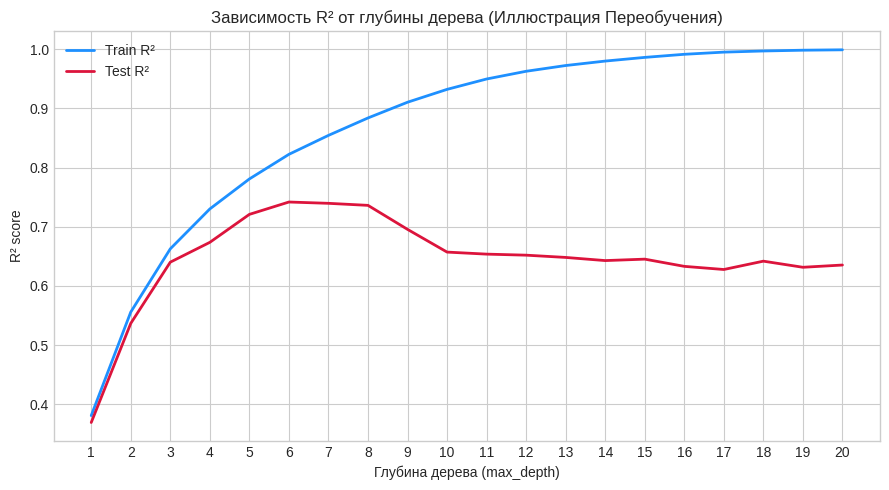

In [172]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score

depths = range(1, 21)
train_r2 = []
test_r2 = []

for depth in depths:
    # Деревьям не нужен StandardScaler, подаем исходный X_train
    dt = DecisionTreeRegressor(max_depth=depth, random_state=42)
    dt.fit(X_train, y_train_log)
    
    # Считаем R² на train и test в логарифмах
    train_r2.append(r2_score(y_train_log, dt.predict(X_train)))
    test_r2.append(r2_score(y_test_log, dt.predict(X_test)))

plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(depths, train_r2, label='Train R²', color='dodgerblue', lw=2)
ax.plot(depths, test_r2, label='Test R²', color='crimson', lw=2)

ax.set_xlabel('Глубина дерева (max_depth)')
ax.set_ylabel('R² score')
ax.set_title('Зависимость R² от глубины дерева (Иллюстрация Переобучения)')
ax.set_xticks(depths)
ax.legend()
plt.tight_layout()
plt.show()

In [173]:
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.metrics import mean_absolute_error

param_grid_dt = {
    'max_depth': [3, 5, 6, 7, 8, 9, 12, 15],
    'min_samples_leaf': [2, 5, 10, 20]
}

kf = KFold(n_splits=5, shuffle=True, random_state=42)

grid_dt = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    param_grid_dt,
    cv=kf,
    scoring='r2',
    n_jobs=-1
)
grid_dt.fit(X_train, y_train_log)

best_dt = grid_dt.best_estimator_
print(f"Лучшие параметры: {grid_dt.best_params_}")
print(f"Лучший R² на кросс-валидации: {grid_dt.best_score_:.4f}")

preds_dt_log = best_dt.predict(X_test)
r2_dt_log = r2_score(y_test_log, preds_dt_log)

preds_dt_price = np.expm1(preds_dt_log)
y_test_price = np.expm1(y_test_log)

r2_dt_dollars = r2_score(y_test_price, preds_dt_price)
mae_dt_dollars = mean_absolute_error(y_test_price, preds_dt_price)

print(f"R² в логарифмах (на тесте): {r2_dt_log:.4f}")
print(f"Тестовый R² (в $): {r2_dt_dollars:.4f}")
print(f"Тестовый MAE (в $): ${mae_dt_dollars:,.2f}")

Лучшие параметры: {'max_depth': 7, 'min_samples_leaf': 10}
Лучший R² на кросс-валидации: 0.7675
R² в логарифмах (на тесте): 0.7468
Тестовый R² (в $): 0.0719
Тестовый MAE (в $): $15,992.42


In [174]:
!pip install catboost -q

In [175]:
import numpy as np
from catboost import CatBoostRegressor
from sklearn.metrics import r2_score, mean_absolute_error

cb = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.05,
    depth=6,
    random_seed=42,
    verbose=100  # Печатает прогресс каждые 100 деревьев
)

cb.fit(
    X_train, y_train_log,
    eval_set=(X_test, y_test_log),
    early_stopping_rounds=50,
    verbose=100
)

preds_cb_log = cb.predict(X_test)
r2_cb_log = r2_score(y_test_log, preds_cb_log)

preds_cb_price = np.expm1(preds_cb_log)
y_test_price = np.expm1(y_test_log)

r2_cb_dollars = r2_score(y_test_price, preds_cb_price)
mae_cb_dollars = mean_absolute_error(y_test_price, preds_cb_price)

print("\n=== Результаты CatBoost ===")
print(f"R² в логарифмах (на тесте): {r2_cb_log:.4f}")
print(f"Тестовый R² (в $): {r2_cb_dollars:.4f}")
print(f"Тестовый MAE (в $): ${mae_cb_dollars:,.2f}")

0:	learn: 0.8249570	test: 0.8399038	best: 0.8399038 (0)	total: 1.82ms	remaining: 1.81s
100:	learn: 0.3376908	test: 0.3962115	best: 0.3962115 (100)	total: 124ms	remaining: 1.11s
200:	learn: 0.3091074	test: 0.3861103	best: 0.3861103 (200)	total: 244ms	remaining: 969ms
300:	learn: 0.2863993	test: 0.3808010	best: 0.3806343 (297)	total: 366ms	remaining: 850ms
400:	learn: 0.2700553	test: 0.3767983	best: 0.3767305 (398)	total: 487ms	remaining: 728ms
500:	learn: 0.2579355	test: 0.3734741	best: 0.3734741 (500)	total: 609ms	remaining: 607ms
600:	learn: 0.2472198	test: 0.3713946	best: 0.3713946 (600)	total: 730ms	remaining: 485ms
700:	learn: 0.2376679	test: 0.3700436	best: 0.3700436 (700)	total: 853ms	remaining: 364ms
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.3699749864
bestIteration = 705

Shrink model to first 706 iterations.

=== Результаты CatBoost ===
R² в логарифмах (на тесте): 0.8184
Тестовый R² (в $): 0.0860
Тестовый MAE (в $): $12,926.07


In [176]:
from catboost import CatBoostRegressor
from sklearn.model_selection import KFold, GridSearchCV
from sklearn.metrics import r2_score, mean_absolute_error
import numpy as np

param_grid_cb = {
    'depth': [4, 6, 8],
    'learning_rate': [0.03, 0.05, 0.1],
    'l2_leaf_reg': [1, 3, 5]
}

cb_base = CatBoostRegressor(
    iterations=500,
    random_seed=42,
    verbose=0  # Отключаем вывод на каждой итерации для чистоты логов
)

kf = KFold(n_splits=3, shuffle=True, random_state=42)

grid_cb = GridSearchCV(
    estimator=cb_base,
    param_grid=param_grid_cb,
    cv=kf,
    scoring='r2',
    n_jobs=-1
)

print("Запуск подбора гиперпараметров для CatBoost...")
grid_cb.fit(X_train, y_train_log)

best_cb = grid_cb.best_estimator_
print(f"Лучшие параметры CatBoost: {grid_cb.best_params_}")
print(f"Лучший R² на кросс-валидации: {grid_cb.best_score_:.4f}")

preds_best_cb_log = best_cb.predict(X_test)
r2_best_cb_log = r2_score(y_test_log, preds_best_cb_log)

preds_best_cb_price = np.expm1(preds_best_cb_log)
y_test_price = np.expm1(y_test_log)

r2_best_cb_dollars = r2_score(y_test_price, preds_best_cb_price)
mae_best_cb_dollars = mean_absolute_error(y_test_price, preds_best_cb_price)

print("\n=== Результаты лучшей модели CatBoost после GridSearch ===")
print(f"Тестовый R² (в логарифмах): {r2_best_cb_log:.4f}")
print(f"Тестовый R² (в $): {r2_best_cb_dollars:.4f}")
print(f"Тестовый MAE (в $): ${mae_best_cb_dollars:,.2f}")

Запуск подбора гиперпараметров для CatBoost...
Лучшие параметры CatBoost: {'depth': 4, 'l2_leaf_reg': 1, 'learning_rate': 0.1}
Лучший R² на кросс-валидации: 0.8389

=== Результаты лучшей модели CatBoost после GridSearch ===
Тестовый R² (в логарифмах): 0.8199
Тестовый R² (в $): 0.0874
Тестовый MAE (в $): $12,949.23


# 6 Сравнение

=== Сводная таблица метрик ===


,Модель,CV R² (log),Test R² (log),Test R² ($),Test MAE ($)
0,Ridge Regressor,0.7708,0.7629,0.0747,"$15,640.30"
1,Decision Tree,0.7675,0.7468,0.0719,"$15,992.42"
2,CatBoost (GridSearch),0.8389,0.8199,0.0874,"$12,949.23"


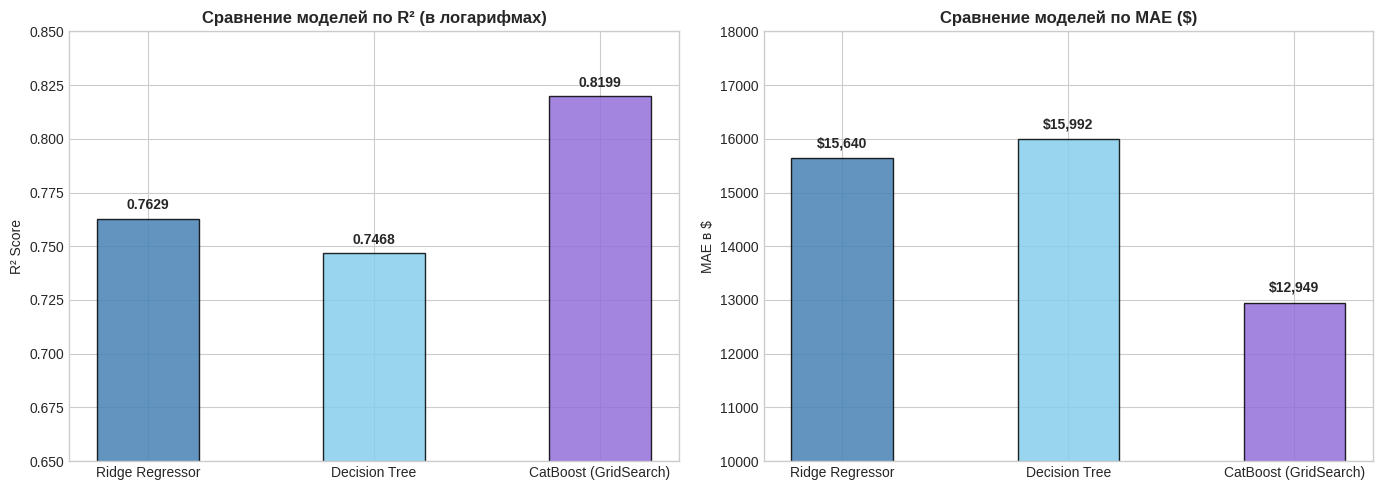

In [177]:
import pandas as pd
import matplotlib.pyplot as plt

results_data = {
    'Модель': ['Ridge Regressor', 'Decision Tree', 'CatBoost (GridSearch)'],
    'CV R² (log)': [grid_ridge.best_score_, grid_dt.best_score_ if 'grid_dt' in locals() else 0.7675, grid_cb.best_score_],
    'Test R² (log)': [r2_log, r2_dt_log, r2_best_cb_log],
    'Test R² ($)': [r2_dollars, r2_dt_dollars, r2_best_cb_dollars],
    'Test MAE ($)': [mae_dollars, mae_dt_dollars, mae_best_cb_dollars]
}

df_results = pd.DataFrame(results_data)

df_display = df_results.copy()
df_display['Test MAE ($)'] = df_display['Test MAE ($)'].apply(lambda x: f"${x:,.2f}")
df_display['CV R² (log)'] = df_display['CV R² (log)'].round(4)
df_display['Test R² (log)'] = df_display['Test R² (log)'].round(4)
df_display['Test R² ($)'] = df_display['Test R² ($)'].round(4)

print("=== Сводная таблица метрик ===")
display(df_display)

plt.style.use('seaborn-v0_8-whitegrid')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

models = results_data['Модель']
r2_scores = results_data['Test R² (log)']
mae_scores = results_data['Test MAE ($)']

colors = ['#4682b4', '#87ceeb', '#9370db']

# График R²
bars1 = ax1.bar(models, r2_scores, color=colors, width=0.45, edgecolor='black', alpha=0.85)
ax1.set_title('Сравнение моделей по R² (в логарифмах)', fontsize=12, fontweight='bold')
ax1.set_ylabel('R² Score')
ax1.set_ylim(0.65, 0.85)

for bar in bars1:
    yval = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, yval + 0.003, f'{yval:.4f}', ha='center', va='bottom', fontweight='bold')

# График MAE
bars2 = ax2.bar(models, mae_scores, color=colors, width=0.45, edgecolor='black', alpha=0.85)
ax2.set_title('Сравнение моделей по MAE ($)', fontsize=12, fontweight='bold')
ax2.set_ylabel('MAE в $')
ax2.set_ylim(10000, 18000)

for bar in bars2:
    yval = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2, yval + 150, f'${yval:,.0f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# 7. Отбор признаков

# 8. Гипотезы и выводы

## Список гипотез
- Использование механизма ранней остановки в CatBoost предотвратит переобучение ансамбля и позволит подобрать оптимальное число итераций.
- Наличие единичных экстремально дорогих автомобилей (выбросов) приведет к тому, что метрика $R^2$ в исходном долларовом масштабе будет значительно ниже $R^2$ в логарифмическом масштабе из-за квадратичного штрафа в MSE.
- При увеличении глубины дерева модель быстро начнёт заучивать обучающие данные, теряя обобщающую способность на тестовой выборке.
- Логарифмирование цены ($y = \ln(1 + \text{price})$) сгладит асимметрию распределения и улучшит качество работы линейных моделей и градиентного бустинга.
- Ансамблевая модель покажет наивысшую точность предсказания цены, превзойдя линейную модель и одиночное дерево решений.
## Краткие результаты
- Использование ранней остановки в CatBoost: **подтверждена** (позволяет остановить обучение при отсутствии улучшений и подобрать оптимальное число итераций без переобучения).
- Влияние выбросов на $R^2$ в долларовом масштабе: **подтверждена** (в логарифмическом масштабе $R^2 > 0.74$, а в исходных долларах из-за единичных сверхдорогих машин падают до $0.07$–$0.08$).
- Заучивание данных при увеличении глубины дерева: **подтверждена** (при max_depth > 7 $R^2$ на обучении стремятся к 1.0, а на тесте падает с 0.74 до 0.63).
- Логарифмирование цены ($y = \ln(1 + \text{price})$): **подтверждена** (сгладило асимметрию и повысило качество всех моделей).
- Преимущество ансамблевой модели: **подтверждена** (CatBoost показал $R^2 = 0.82$, превзойдя Ridge с $0.76$ и Decision Tree с $0.75$). 